In [1]:
"""
Mask a raster to the boundary of a vector layer.

Everything OUTSIDE the (optionally buffered) vector geometry is set to nodata.

Dependencies:
    pip install rasterio geopandas shapely
"""

import geopandas as gpd
import rasterio
from rasterio.mask import mask


def mask_raster_by_vector(
    raster_path,
    vector_path,
    output_path,
    buffer=0.0,
    nodata=None,
    crop=True,
    all_touched=False,
    invert=False,
):
    """
    Mask the area outside a vector boundary as nodata in a raster.

    Parameters
    ----------
    raster_path : str
        Path to the input raster (e.g. GeoTIFF).
    vector_path : str
        Path to the input vector (anything geopandas can read: .shp, .gpkg, .geojson...).
    output_path : str
        Path for the masked output raster.
    buffer : float, default 0.0
        Distance to buffer the vector geometry before masking. Units are those of
        the RASTER's CRS (typically metres for a projected CRS, degrees for a
        geographic CRS). Use a positive value to expand the boundary, a negative
        value to shrink it. 0 disables buffering.
    nodata : int or float, optional
        Nodata value to write for masked-out pixels. If None, the raster's existing
        nodata value is used; if the raster has none, 0 is used as a fallback.
    crop : bool, default True
        If True, crop the output extent to the (buffered) vector bounds. If False,
        keep the original raster extent and only mask values.
    all_touched : bool, default False
        If True, pixels touched by the geometry boundary are included (not just
        those whose centre falls inside).
    invert : bool, default False
        If True, mask INSIDE the geometry instead of outside (i.e. cut a hole).

    Returns
    -------
    str
        The output_path that was written.
    """
    # Read the vector
    gdf = gpd.read_file(vector_path)
    if gdf.empty:
        raise ValueError(f"Vector layer '{vector_path}' contains no features.")

    with rasterio.open(raster_path) as src:
        raster_crs = src.crs

        # Align the vector CRS to the raster CRS so the buffer distance and the
        # mask are both expressed in the raster's coordinate units.
        if gdf.crs is None:
            raise ValueError(
                "Vector has no CRS defined; cannot align it to the raster."
            )
        if raster_crs is not None and gdf.crs != raster_crs:
            gdf = gdf.to_crs(raster_crs)

        if raster_crs is not None and raster_crs.is_geographic and buffer:
            print(
                "Warning: raster CRS is geographic; the buffer is interpreted in "
                "degrees, which is rarely what you want. Consider a projected CRS."
            )
        gdf.plot();
        # Apply the buffer and collect geometries
        geoms = gdf.geometry
        try:
            geoms = geoms.make_valid()
        except AttributeError:
            geoms = geoms.buffer(0)
        # Drop anything that didn't survive repair before we buffer.
        geoms = geoms[geoms.notna() & ~geoms.is_empty]
        if geoms.empty:
            raise ValueError("No valid geometry left after repairing the vector.")
 
        # Apply the buffer and collect geometries
        if buffer:
            geoms = geoms.buffer(buffer)
        # Drop empties (can happen with a negative buffer) and dissolve to a list
        geoms = [g for g in geoms if g is not None and not g.is_empty]
        if not geoms:
            raise ValueError(
                "No geometry left to mask with (check the buffer value)."
            )

        # Resolve the nodata value
        out_nodata = nodata if nodata is not None else src.nodata
        if out_nodata is None:
            out_nodata = 0  # last-resort fallback

        out_image, out_transform = mask(
            src,
            geoms,
            crop=crop,
            all_touched=all_touched,
            invert=invert,
            nodata=out_nodata,
            filled=True,
        )

        out_meta = src.meta.copy()
        out_meta.update(
            {
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "nodata": out_nodata,
            }
        )

        with rasterio.open(output_path, "w", **out_meta) as dst:
            dst.write(out_image)

    return output_path

{'11': '11am'}


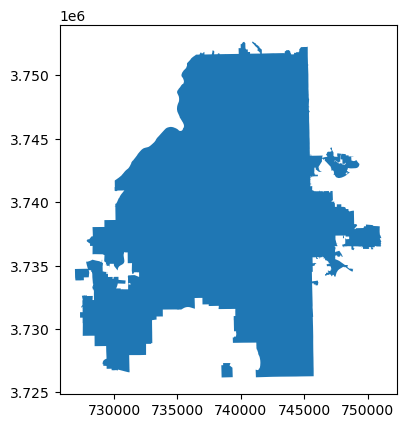

In [8]:
if __name__ == "__main__":
    # Example usage
    paths = {}
    time_list = ["11"]

    # Dictionary comprehension to format each hour
    time_lists = {
        hour: f"{int(hour) if int(hour) <= 12 else int(hour) - 12}{'am' if int(hour) < 12 else 'pm'}"
        for hour in time_list
    }
    print(time_lists)
    for time, hour in time_lists.items():
        INPUT_RASTER = f"/storage/project/r-rbasu31-0/hyu483/City_Atlanta/Output_UTCI/{time}/Merged_Output/UTCI_merged_final.tif"
        BOUNDARY_PATH = "/storage/project/r-rbasu31-0/hyu483/City_Atlanta/Atlanta_City_Limits.geojson"
        FINAL_OUTPUT = f"/storage/project/r-rbasu31-0/hyu483/City_Atlanta/Output_UTCI/UTCI_{hour}.tif"
        mask_raster_by_vector(
            raster_path=INPUT_RASTER,
            vector_path=BOUNDARY_PATH,
            output_path=FINAL_OUTPUT,
            buffer=200,      # 100 metres outward (assuming a projected CRS)
            # nodata=-9999,
        )